# Homework 8

Домашнее задание состоит из двух частей: линейная регрессия и логистическая регрессия.

## Дополнительные задачи

Если вы считаете, что необходимо выполнить дополнительные шаги, помимо указанных в заданиях ниже, добавьте их в соответствующие разделы по ходу выполнения задания. Используйте заголовок **Дополнительно** в формате **Markdown**, чтобы четко обозначить ваши идеи и их реализацию. Убедитесь, что ваши дополнительные шаги логично дополняют основную задачу и помогают углубить анализ или улучшить модель.


# Homework 8.1 - Linear Regression

## Датасет

Этот набор данных содержит информацию о домах в различных районах Калифорнии, а также сводную статистику, основанную на данных переписи 1990 года. Обратите внимание, что данные не обработаны, поэтому перед анализом потребуется выполнить необходимые шаги по очистке и предварительной обработке.

### Задание 1. Exploratory Data Analysis (EDA) & Data Cleaning

**1.1.** Загрузка данных:
   - Импортируйте необходимые библиотеки (`pandas`, `numpy`, `matplotlib`, `seaborn`).
   - Загрузите данные из файла `housing.csv`.
   - Ознакомьтесь с данными: используйте методы `.head()`, `.info()`, `.describe()`, и т.п. для анализа структуры и ключевых характеристик.


In [1]:
# Ваш код:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

house_data = pd.read_csv("housing.csv")

In [2]:
house_data.head(n=3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [3]:
house_data.sample(50)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17072,-122.21,37.52,18.0,2962.0,945.0,1639.0,851.0,2.7399,87500.0,NEAR BAY
111,-122.25,37.82,32.0,3809.0,1098.0,1806.0,1022.0,2.6429,218500.0,NEAR BAY
11173,-117.97,33.83,22.0,3310.0,688.0,1807.0,674.0,4.0185,200900.0,<1H OCEAN
7015,-118.08,33.97,35.0,825.0,155.0,590.0,144.0,4.6333,161200.0,<1H OCEAN
743,-122.11,37.67,38.0,1035.0,247.0,599.0,224.0,3.0917,167200.0,NEAR BAY
16641,-120.66,35.29,16.0,2272.0,629.0,1689.0,649.0,1.7031,195000.0,NEAR OCEAN
232,-122.19,37.80,52.0,1813.0,271.0,637.0,277.0,4.0114,263400.0,NEAR BAY
14107,-117.11,32.75,46.0,695.0,182.0,601.0,195.0,2.4219,90600.0,NEAR OCEAN
13746,-117.15,34.07,15.0,1852.0,316.0,906.0,298.0,5.3526,129800.0,INLAND
3091,-118.45,35.62,18.0,2304.0,527.0,782.0,390.0,1.4141,75800.0,INLAND


In [4]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
house_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
for feature in house_data.columns:
    print(f"Признак: {feature}\nКол-во уникальных значений: {len(house_data[feature].unique())}")
    print(house_data[feature].unique()[:10])
    print("---------------")

Признак: longitude
Кол-во уникальных значений: 844
[-122.23 -122.22 -122.24 -122.25 -122.26 -122.27 -122.28 -122.29 -122.3
 -122.21]
---------------
Признак: latitude
Кол-во уникальных значений: 862
[37.88 37.86 37.85 37.84 37.83 37.82 37.81 37.8  37.79 37.77]
---------------
Признак: housing_median_age
Кол-во уникальных значений: 52
[41. 21. 52. 42. 50. 40. 49. 48. 51. 43.]
---------------
Признак: total_rooms
Кол-во уникальных значений: 5926
[ 880. 7099. 1467. 1274. 1627.  919. 2535. 3104. 2555. 3549.]
---------------
Признак: total_bedrooms
Кол-во уникальных значений: 1924
[ 129. 1106.  190.  235.  280.  213.  489.  687.  665.  707.]
---------------
Признак: population
Кол-во уникальных значений: 3888
[ 322. 2401.  496.  558.  565.  413. 1094. 1157. 1206. 1551.]
---------------
Признак: households
Кол-во уникальных значений: 1815
[ 126. 1138.  177.  219.  259.  193.  514.  647.  595.  714.]
---------------
Признак: median_income
Кол-во уникальных значений: 12928
[8.3252 8.3014 7.257

**Ocean_proximity** - единственный признак с **непродолжительными значениями**<br>по совместительству так же **единственный категориальный признак**

**1.2.** Обработка пропущенных значений:
   - Проверьте наличие пропусков в данных (`isnull().sum()`).
   - Заполните пропуски средними значениями или медианой для числовых данных.

In [7]:
# Ваш код:
print(house_data.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Так как в признаке total_bedrooms большое стандартное отклонение и данные перекошены, мы будем заменять медианой

In [8]:
house_data.fillna(house_data["total_bedrooms"].median(), inplace=True)

**1.3.** Анализ распределения данных:
   - Постройте гистограммы для всех числовых признаков, чтобы понять их распределение.
   - Обратите внимание на перекосы (skewness) и примените логарифмическую трансформацию, если необходимо.


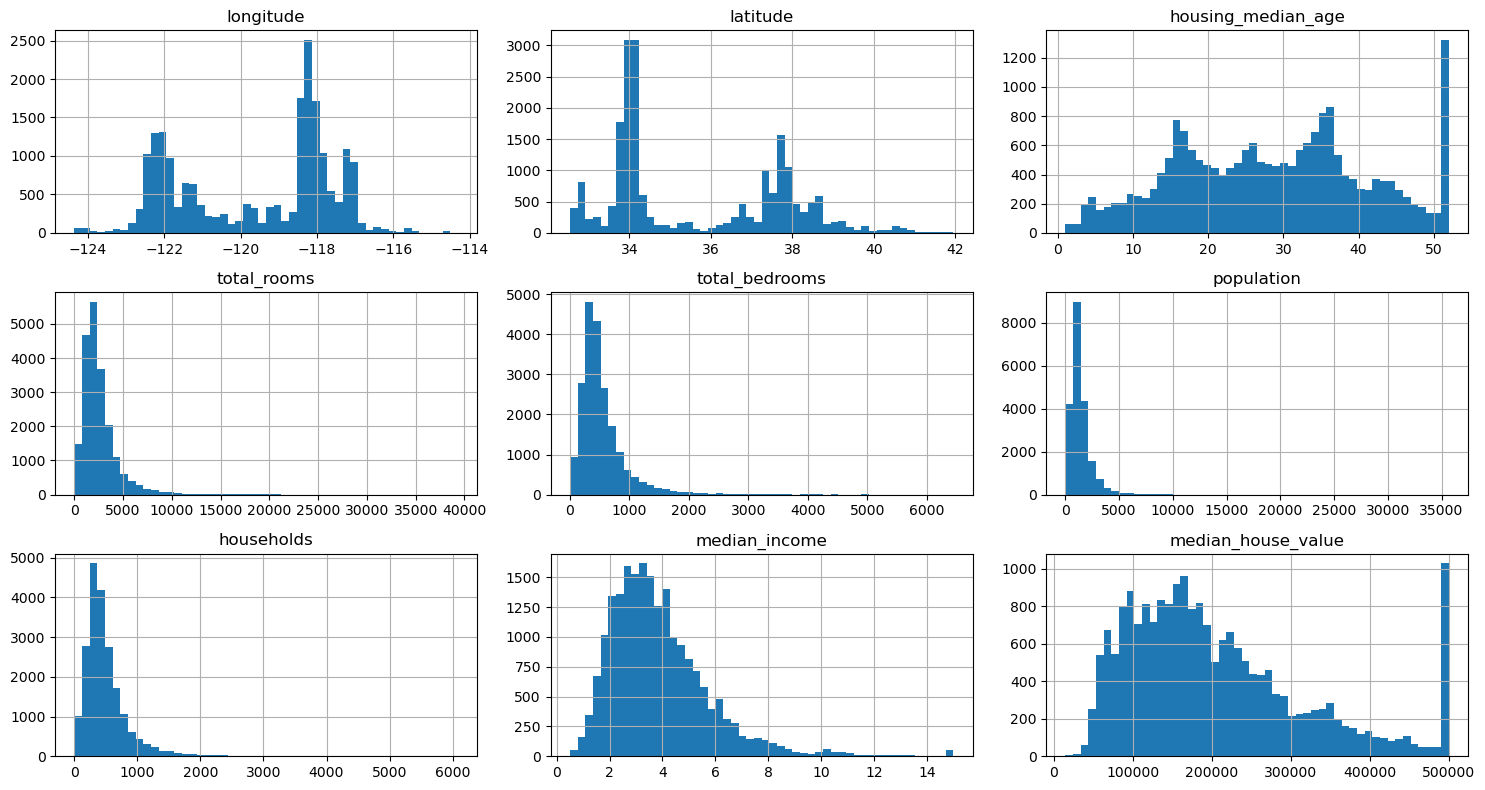

In [9]:
# Ваш код:
house_data.hist(figsize=(15,8), bins=50)
plt.tight_layout()
plt.show()

In [10]:
house_data.select_dtypes(["float", "int"]).skew()

longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.481141
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64

Признаки в которых замечен перекос:
- Кол-во комнат в районе
- Кол-во спален в районе
- Кол-во людей проживающих в районе
- Кол-во групп-людей проживающих под одной крышей в районе
- Медиана зарплаты в районе
- Медиана цены дома в районе
<br> В основном перекос в правую сторону
<br>Для этих признаков мы применим *логарифмическую трансформацию* и заново посмотрим на распределения

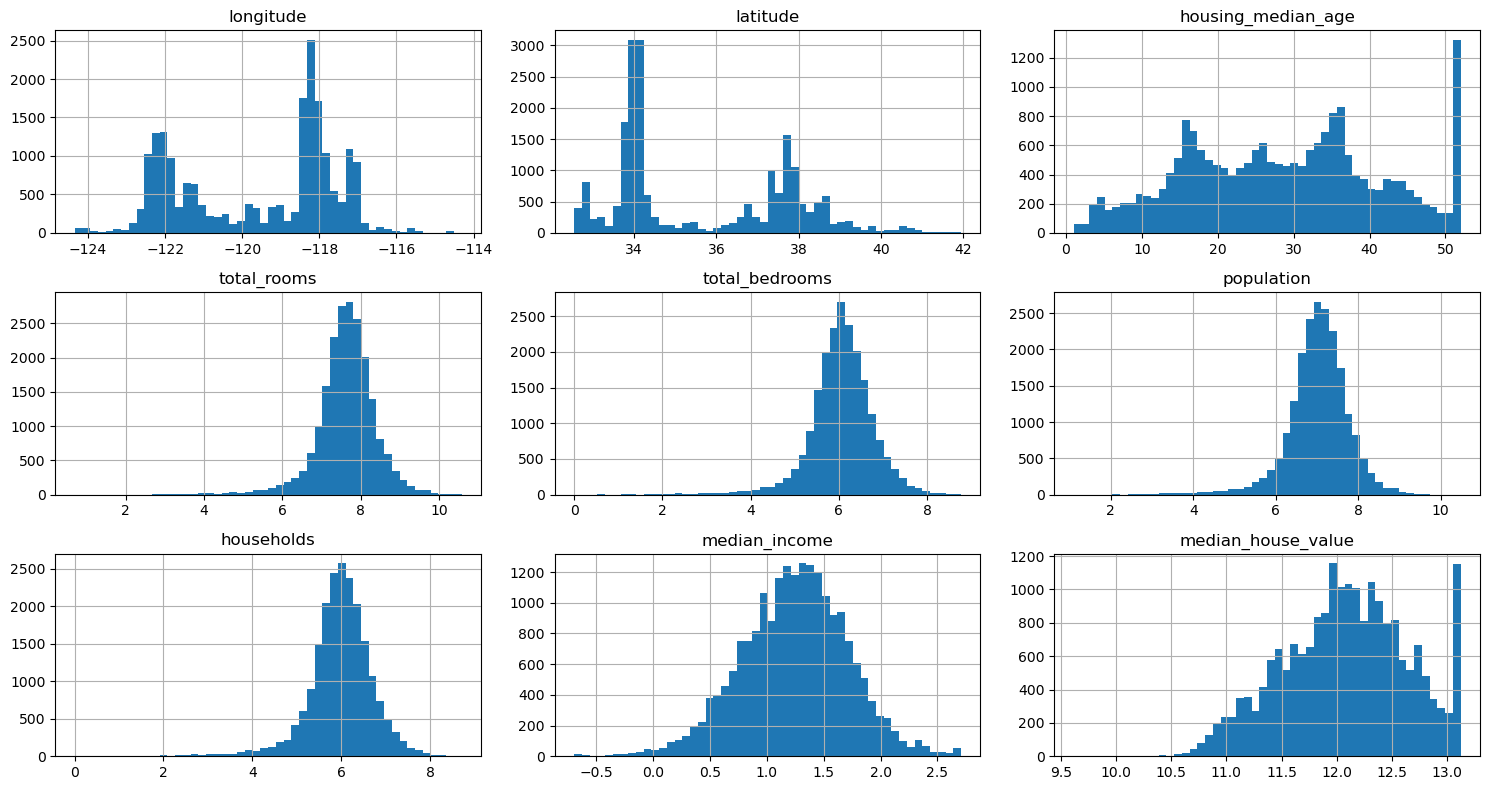

In [11]:
house_log_data = house_data.copy()

for feature in ["total_rooms", "total_bedrooms", "population", "households", "median_income", "median_house_value"]:
    house_log_data[feature] = np.log(house_log_data[feature])

house_log_data.hist(figsize=(15,8), bins=50)
plt.tight_layout()
plt.show()

    Видно что распределения стали более симметричными, но у некоторых признаков есть хвосты, что указывает на наличие выбросов

**1.4.** Поиск выбросов:
   - Постройте диаграммы "ящик с усами" (boxplots) для основных признаков.
   - Удалите или скорректируйте выбросы, если они существенно искажают данные.


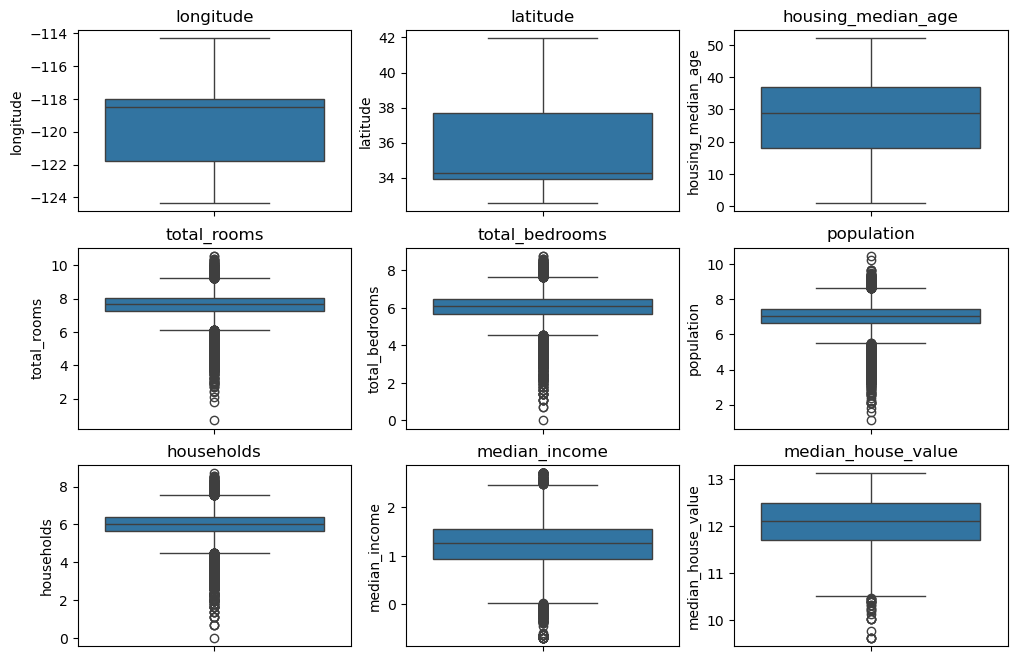

In [12]:
# Ваш код:
house_log_numeric_data = house_log_data.select_dtypes(["float", "int"])
fig, axs = plt.subplots(3,3, figsize=(12,8))
for idx, ax in enumerate(axs.flatten()):
    sns.boxplot(house_log_numeric_data.iloc[:, idx], ax=ax)
    ax.set_title(house_log_numeric_data.columns[idx])

Как мы можем видеть в следующих признаках присутствует значительное наличие выбросов:
- Total_rooms
- Total_bedrooms
- Population
- households
- median_income
<br> Давайте уберем эти выбросы

In [13]:
def getOutliers(df):
    # Сохраним количество выбросов и их индексы для каждого признака для дальнейшего просмотра и чистки
    outlier_count = {}
    outlier_indices = set()
    # Используем метод межквартильного размаха
    for feature in df.columns:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound))
        outlier_count[feature] = (outliers.sum(), df[outliers].index)
        # Используем сет чтобы не добавлять повторяющиеся индексы
        outlier_indices.update(df[outliers].index)
    return outlier_count, outlier_indices

outlier_count, outliers = getOutliers(house_log_numeric_data)
outlier_count_df = pd.DataFrame(data=[_[0] for _ in outlier_count.values()], index=outlier_count.keys(), columns=["Count"])
print(outlier_count_df.sort_values("Count", ascending=False))

print("Количество наблюдений до чистки от выбросов: {}".format(house_log_data.shape[0]))
house_log_data = house_log_data.drop(outliers)
print("Количество наблюдений после чистки: {}".format(house_log_data.shape[0]))
print("Всего выбросов удалено: {}".format(len(outliers)))

                    Count
total_rooms           956
households            885
population            847
total_bedrooms        841
median_income         277
median_house_value     26
longitude               0
latitude                0
housing_median_age      0
Количество наблюдений до чистки от выбросов: 20640
Количество наблюдений после чистки: 19206
Всего выбросов удалено: 1434


    Посмотрим на распределения после чистки:

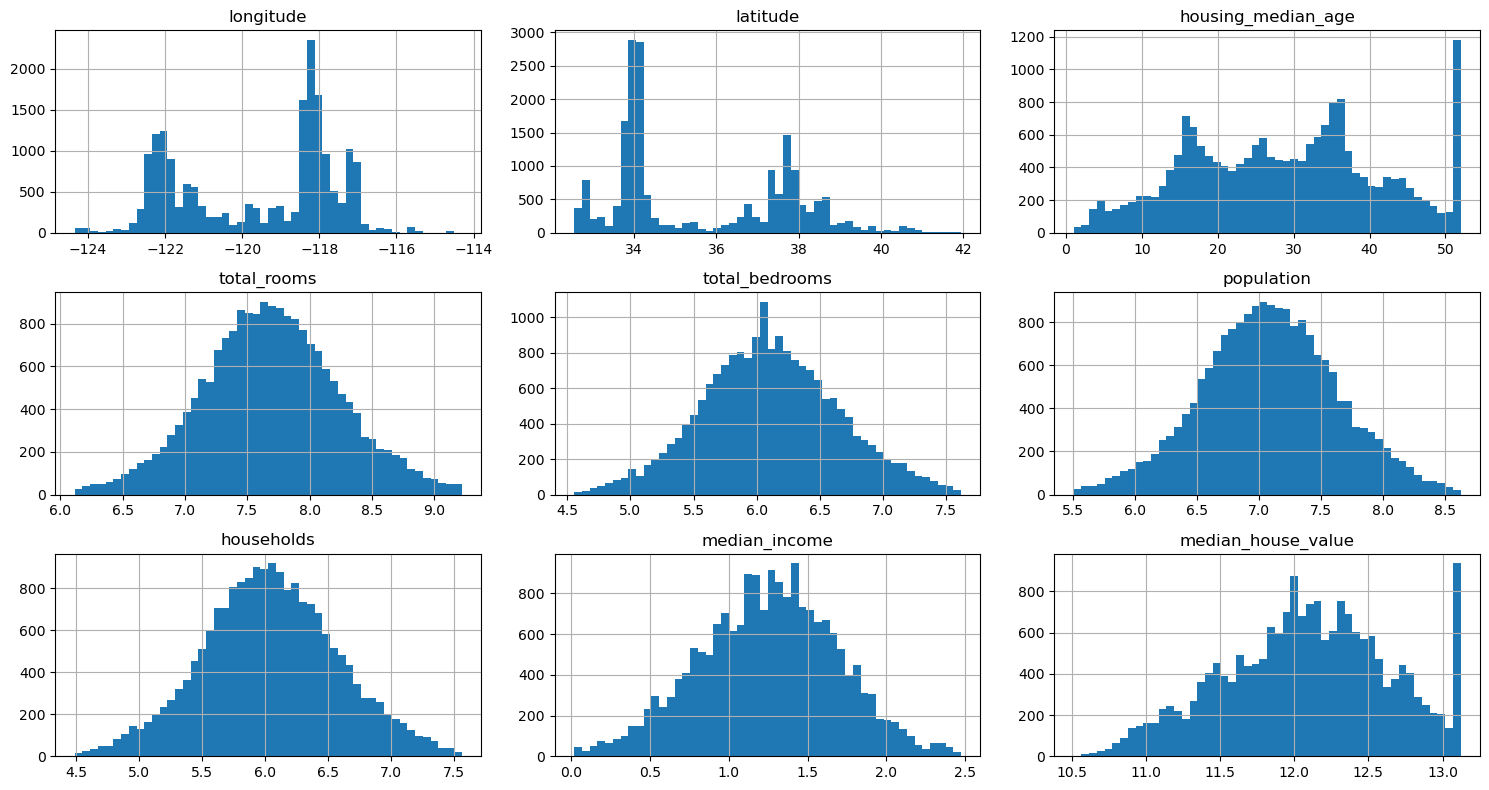

In [14]:
house_log_data.hist(figsize=(15,8), bins=50)
plt.tight_layout()
plt.show()

**1.5.** Корреляционный анализ:
   - Постройте тепловую карту корреляции между признаками.
   - Определите признаки, которые имеют сильную корреляцию с целевой переменной (`median_house_value`), а также признаки с высокой мультиколлинеарностью.


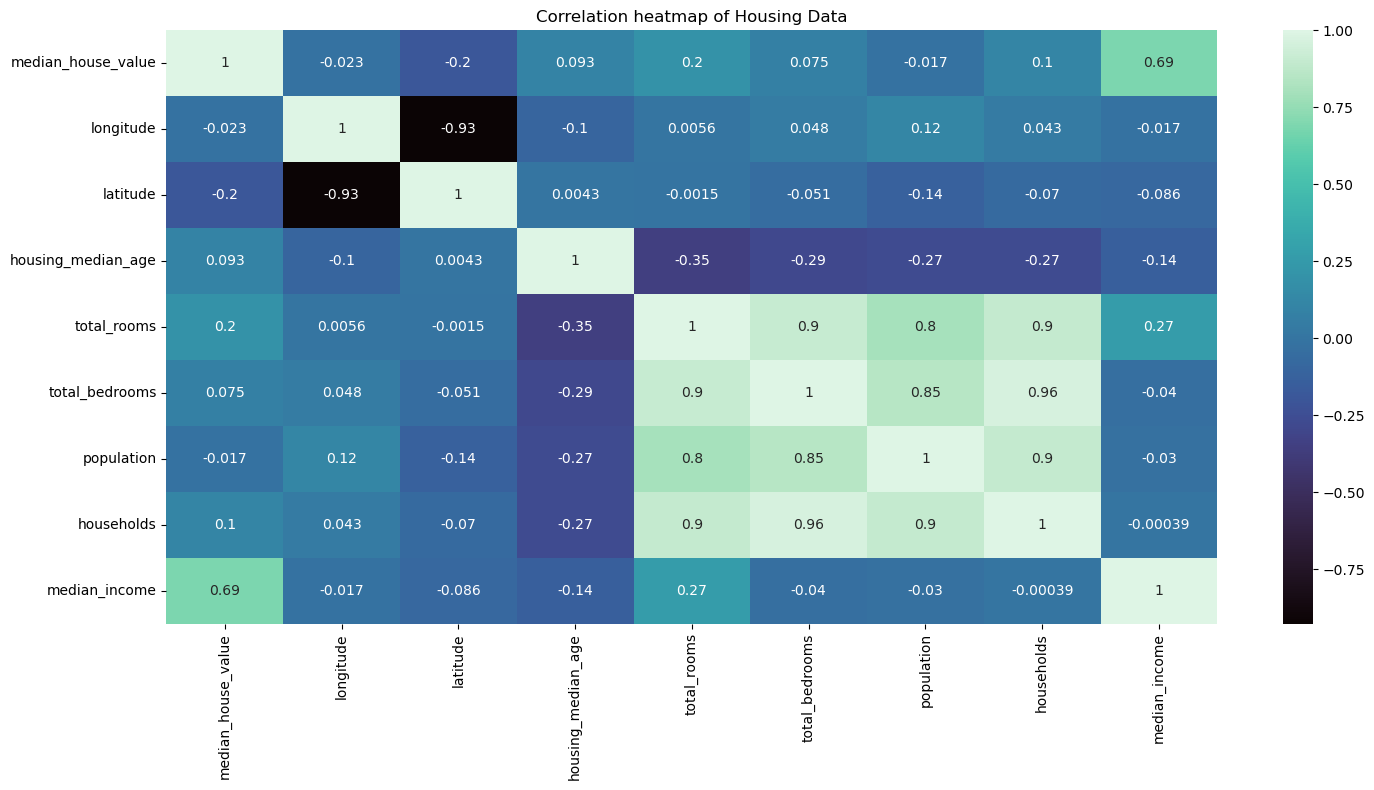

In [15]:
# Ваш код:
house_log_data = house_log_data.loc[:, ["median_house_value"] + [col for col in house_log_data if col != "median_house_value"]]
house_corr_pearson = house_log_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(house_corr_pearson, annot=True, cmap="mako")
plt.title("Correlation heatmap of Housing Data")
plt.tight_layout()
plt.show()

**Признаки имеющую корреляцию с таргетом(median_hosue_value):**
- median_income(сильная корреляция)
- Latitude(слабая корреляция)
- Total_rooms(слабая корреляция)
- households(слабая корреляция)

<br>**Признаки имеющие мультиколлинеарность:**
- Total_rooms, Total_bedrooms, population, households - сильная мультиколлинеарность
- Latitude и longtitude - сильная мультиколлинеарность
- Housing и Total_rooms, Total_bedrooms, population, households - средняя мультиколлинеарность
- Median_income и total_rooms - средняя мультиколлинеарность

**1.6.** Кодирование категориальных данных:
   - Преобразуйте категориальный признак `ocean_proximity` в числовой с помощью метода one-hot encoding.


In [16]:
house_log_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     8637
INLAND        5925
NEAR OCEAN    2502
NEAR BAY      2137
ISLAND           5
Name: count, dtype: int64

**NOTE:** Удалим признак is_ISLAND так как недостаточно данных

In [17]:
# Ваш код:
house_log_dummy_data = pd.get_dummies(house_log_data, columns=["ocean_proximity"], dtype=np.int64, prefix="is")
house_log_dummy_data.head()

,median_house_value,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,is_<1H OCEAN,is_INLAND,is_ISLAND,is_NEAR BAY,is_NEAR OCEAN
0,13.022764,-122.23,37.88,41.0,6.779922,4.859812,5.774552,4.836282,2.119287,0,0,0,1,0
1,12.789684,-122.22,37.86,21.0,8.867709,7.008505,7.783641,7.037028,2.116424,0,0,0,1,0
2,12.771671,-122.24,37.85,52.0,7.290975,5.247024,6.206576,5.176150,1.982022,0,0,0,1,0
3,12.740517,-122.25,37.85,52.0,7.149917,5.459586,6.324359,5.389072,1.730434,0,0,0,1,0
4,12.743151,-122.25,37.85,52.0,7.394493,5.634790,6.336826,5.556828,1.347086,0,0,0,1,0


**1.7.** Создание новых признаков (опционально):
   - Рассчитайте и добавьте новые признаки


In [18]:
# Ваш код:

**1.8.** Стандартизация данных (опционально):
   - Нормализуйте числовые признаки с помощью метода стандартизации (например, `StandardScaler` из `sklearn`).


In [19]:
# Ваш код:

**1.9.** Визуализация :
- Постройте диаграммы рассеяния для ключевых признаков.
- Постройте распределение целевой переменной, чтобы выявить возможные ограничения или закономерности.

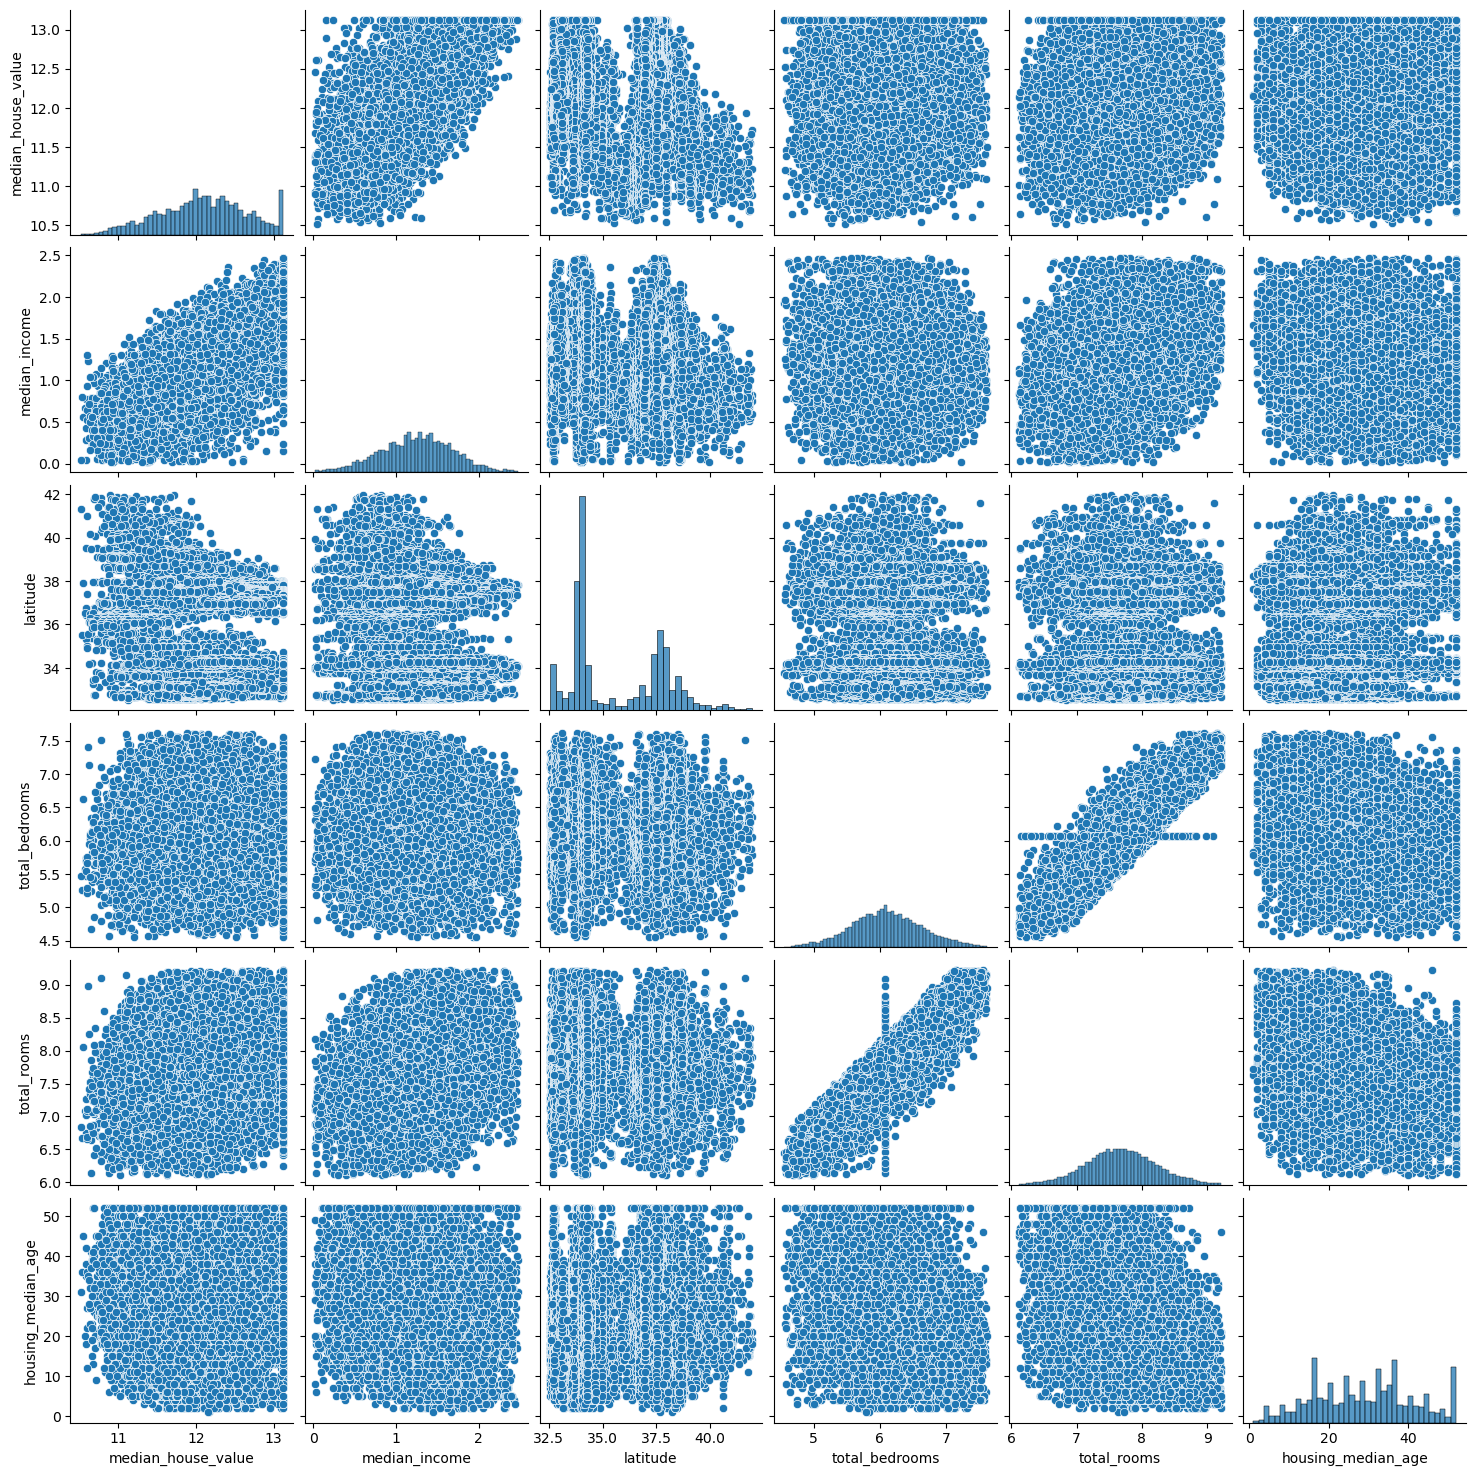

In [20]:
# Ваш код:
house_top_features = house_log_dummy_data[["median_house_value", "median_income", "latitude", "total_bedrooms", "total_rooms", "housing_median_age"]]
sns.pairplot(house_top_features)

### Задание 2. Разделение данных и обучение моделей

**2.1.** Разделите данные на матрицу признаков $X$ и целевую переменную $y$.

In [21]:
# Ваш код:
X = house_log_dummy_data.drop(columns=["median_house_value", "is_ISLAND"])
y = house_log_dummy_data.loc[:, "median_house_value"]

**2.2.** Разделите данные на тренировочный (80%) и тестовый (20%) наборы.

In [22]:
# Ваш код:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**2.3.** Обучите модель линейной регрессии на тренировочном наборе.

Оцените модель на тестовой выборке, используя метрики:
- Коэффициент детерминации ($R^2$).
- Среднеквадратическая ошибка ($RMSE$).


In [23]:
# Ваш код:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
import statsmodels.api as sm

def evaluate_model(model, X, y):
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    adj_r2 = 1 - (1-r2) * (len(y)-1)/(len(y)-X.shape[1]-1)
    rmse = root_mean_squared_error(y, preds)
    results = {
        "model": type(model).__name__,
        "r2": r2,
        "r2_adj": adj_r2,
        "rmse": rmse
    }
    
    for metric, res in results.items():
        print(metric + ": " + str(res))
    return results
results = []
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Результаты на тренировочном сете:")
base_train_result = evaluate_model(lin_reg, X_train, y_train)

print("Результаты на тест сете:")
base_test_result = evaluate_model(lin_reg, X_test, y_test)
results.append(base_test_result)

Результаты на тренировочном сете:
model: LinearRegression
r2: 0.7234792406055688
r2_adj: 0.7232630821069216
rmse: 0.2935199016903412
Результаты на тест сете:
model: LinearRegression
r2: 0.7277530778506894
r2_adj: 0.7268998621113862
rmse: 0.2914111993105933


**OLS**

In [24]:
X = sm.add_constant(X_train)
ols = sm.OLS(y_train, X)
results_ols = ols.fit()
print(results_ols.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     3347.
Date:                Wed, 25 Dec 2024   Prob (F-statistic):               0.00
Time:                        21:32:46   Log-Likelihood:                -2967.2
No. Observations:               15364   AIC:                             5960.
Df Residuals:                   15351   BIC:                             6060.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.0257      0

2.4. Интерпретируйте коэффициенты модели.
- Какие признаки оказывают наибольшее влияние на целевую переменную?
- Укажите направление влияния (положительное или отрицательное).

In [25]:
# Ваш код:
def getCoefDf(model):
    coefs = np.hstack((model.coef_, model.intercept_))
    features_in = list(model.feature_names_in_) + ["intercept"]
    coef_values = pd.DataFrame(data=coefs, index=features_in, columns=["coef_value"])
    coef_values = coef_values.sort_values("coef_value", ascending=True)
    # Сделаем датафрейм из абсолютных значений чтобы оценить значение признаков
    coef_values_abs = pd.DataFrame(data=abs(coefs), index=features_in, columns=["coef_value"])
    coef_values_abs = coef_values_abs.sort_values("coef_value", ascending=False)
    return coef_values, coef_values_abs

lin_reg_coefs, lin_reg_coefs_abs = getCoefDf(lin_reg)
print(lin_reg_coefs)
print(lin_reg_coefs_abs)

                    coef_value
intercept            -1.025745
is_INLAND            -0.730572
is_NEAR BAY          -0.537395
is_NEAR OCEAN        -0.518185
is_<1H OCEAN         -0.475063
population           -0.445729
total_rooms          -0.216619
longitude            -0.153935
latitude             -0.152815
housing_median_age    0.004110
households            0.324415
total_bedrooms        0.396685
median_income         0.828722
                    coef_value
intercept             1.025745
median_income         0.828722
is_INLAND             0.730572
is_NEAR BAY           0.537395
is_NEAR OCEAN         0.518185
is_<1H OCEAN          0.475063
population            0.445729
total_bedrooms        0.396685
households            0.324415
total_rooms           0.216619
longitude             0.153935
latitude              0.152815
housing_median_age    0.004110


Как можно увидеть из таблицы наибольшее влияние на таргет имеют признаки:
- median_income
- признаки one-hot encoded из положения дома по отношению к океану
- Кол-во людей проживающих в районе
- Кол-во спальных комнат в районе
<br><br>
    Из них - отрицательно влияют следующие признаки:
- Кол-во людей, проживающих в районе
- признаки one-hot encoded из положения дома по отношению к океану

**2.5.** Обучите модель Ridge на тренировочной выборке.
- Подберите гиперпараметр alpha через кросс-валидацию.
- Оцените модель с использованием $R^2$ и $RMSE$.
- Объясните, как регуляризация уменьшает величину коэффициентов и предотвращает переобучение.


In [26]:
# Ваш код:
from sklearn.linear_model import RidgeCV
alpha_range = np.logspace(-4, 2, 50)

ridge = RidgeCV(alphas=alpha_range, cv=5, scoring="neg_root_mean_squared_error")
ridge.fit(X_train, y_train)

print("Результаты на тренировочном сете:")
ridge_train_result = evaluate_model(ridge, X_train, y_train)
print("Результаты на тест сете:")
ridge_test_result = evaluate_model(ridge, X_test, y_test)

results.append(ridge_test_result)

ridge_coefs, ridge_coefs_abs = getCoefDf(ridge)
print(ridge_coefs)
print(ridge_coefs_abs)

Результаты на тренировочном сете:
model: RidgeCV
r2: 0.7234792406017857
r2_adj: 0.7232630821031356
rmse: 0.293519901692349
Результаты на тест сете:
model: RidgeCV
r2: 0.7277530743779008
r2_adj: 0.726899858627714
rmse: 0.2914112011692176
                    coef_value
intercept            -1.025814
is_INLAND            -0.730512
is_NEAR BAY          -0.537335
is_NEAR OCEAN        -0.518125
is_<1H OCEAN         -0.475002
population           -0.445729
total_rooms          -0.216619
longitude            -0.153936
latitude             -0.152815
housing_median_age    0.004110
households            0.324414
total_bedrooms        0.396685
median_income         0.828722
                    coef_value
intercept             1.025814
median_income         0.828722
is_INLAND             0.730512
is_NEAR BAY           0.537335
is_NEAR OCEAN         0.518125
is_<1H OCEAN          0.475002
population            0.445729
total_bedrooms        0.396685
households            0.324414
total_rooms        

Ridge добавляет alpha * сумму квадратов коэффициентов в функцию потери, тем самым добавляет значение к функции потери если коэффициенты модели огромные.
Это позволяет модели быть менее чувствительной к признакам, с большими коэффициентами. Хорошо работает когда есть мультиколлинеарность и когда данные шумные. В этом случае Ridge расставляет пропорционально коэффициенты и предотвращает тем самым переобучение

**2.6.** Обучите модель Lasso на тренировочной выборке.
- Подберите гиперпараметр alpha через кросс-валидацию.
- Оцените модель с использованием $R^2$ и $RMSE$.
- Укажите, какие признаки были обнулены, и объясните, как Lasso помогает упростить модель.

In [27]:
# Ваш код:

from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=alpha_range, cv=5, random_state=42)

lasso.fit(X_train, y_train)

print("Результаты на тренировочном сете:")
lasso_train_result = evaluate_model(lasso, X_train, y_train)
print("Результаты на тест сете:")
lasso_test_result = evaluate_model(lasso, X_test, y_test)

results.append(lasso_test_result)

lasso_coefs, lasso_coefs_abs = getCoefDf(lasso)
print(lasso_coefs)
print(lasso_coefs_abs)

Результаты на тренировочном сете:
model: LassoCV
r2: 0.723190100257125
r2_adj: 0.7229737157351451
rmse: 0.29367331923669326
Результаты на тест сете:
model: LassoCV
r2: 0.7276648967928105
r2_adj: 0.7268114046960525
rmse: 0.2914583896831237
                    coef_value
intercept            -1.596925
population           -0.443458
is_INLAND            -0.213138
total_rooms          -0.206028
longitude            -0.154511
latitude             -0.153654
is_NEAR BAY          -0.017844
is_NEAR OCEAN        -0.000000
housing_median_age    0.004119
is_<1H OCEAN          0.042614
households            0.315299
total_bedrooms        0.393077
median_income         0.823808
                    coef_value
intercept             1.596925
median_income         0.823808
population            0.443458
total_bedrooms        0.393077
households            0.315299
is_INLAND             0.213138
total_rooms           0.206028
longitude             0.154511
latitude              0.153654
is_<1H OCEAN     

### Задание 3. Предсказания на тестовой выборке и выводы

**3.1.** Выполните предсказания на тестовых данных для каждой модели (Linear, Ridge, Lasso, ElasticNet).

In [28]:
# Ваш код:
results = pd.DataFrame(results).set_index("model")

**3.2.** Сравните метрики между моделями

In [29]:
# Ваш код:
results

,r2,r2_adj,rmse
model,,,
LinearRegression,0.727753,0.726900,0.291411
RidgeCV,0.727753,0.726900,0.291411
LassoCV,0.727665,0.726811,0.291458


**3.3.** Сделайте выводы
- Какая модель лучше справляется с данными?
- Какие признаки оказались наиболее значимыми?
- Как регуляризация повлияла на качество модели и коэффициенты?


1. Результаты моделей:
    - Ridge и Linear Regression справляются чуть лучше чем Lasso
2. Самые значимые признаки:
    - Median_income - как было видно из корреляционного анализа, заработок наиболее значим для цены здания
    - is_INLAND - здания которые находятся подальше от берега снижаются в стоимости
    - population - Чем больше людей проживает в районе здания, тем меньше его стоимость
    - total_bedrooms - Чем больше спальных комнатв районе здания, тем больше его стоимость
3. Эффект Регуляризации:
    - Lasso занулила признак is_NEAR OCEAN, что означает что этот признак малозначим
    - Ridge почти не изменил коэффициенты, так как данные уже нормализованы благодаря лог трансформации

In [30]:
# Ваш код:

# Homework 8.2 - Logistic Regression

## Датасет

Этот датасет содержит 14 признаков. `target` - целевая переменная, которая  указывает на наличие сердечного заболевания у пациента. Это целое число: `0` — отсутствие заболевания, `1` — наличие заболевания.

Вам необходимо создать модель (логистическая регрессия), которая предсказывает вероятность сердечного заболевания.

**Исходный источник:**  
[Heart Disease Dataset](https://archive.ics.uci.edu/ml/datasets/Heart+Disease)



### Задание 1. Exploratory Data Analysis (EDA)

Делайте с данными всё, что считаете нужным, чтобы лучше их понять. Исследуйте и анализируйте на своё усмотрение.

**Таблица Признаков**:
| Признак | Описание |
|---|---|
| age | Возраст |
| sex | Пол<br>1 - мужчина<br>0 - женщина |
| cp | Вид грудной боли:<br>0: Типичная стенокардия<br>1: Нетипичная стенокардия<br>2: Нестенокардийная боль<br>3: Бессимптомная |
| trestbps | Давление в состоянии покоя |
| chol | Холестерин |
| fbs | Уровень сахара в крови натощак:<br>0: меньше 120<br>1: больше 120 |
| restecg | Результаты электрокардиографии в состоянии покоя:<br>0: Нормальное<br>1: Имеет аномалию зубца ST-T<br>2: Показывает вероятную или определенную гипертрофию левого желудочка |
| thalach | Максимально достигнутый пульс |
| exang | Стенокардия, вызванная физическими нагрузками:<br>0: Нет<br>1: Да |
| oldpeak | Угнетение сегмента ST, вызванное физической нагрузкой по сравнению с покоем |
| slope | Наклон пиковой нагрузки сегмента ST:<br>0: Восходящий<br>1: Плоский<br>2: Нисходящий |
| ca | Количество крупных сосудов (0-3), окрашенных флюороскопией |
| thal | Наследственное заболевание крови |

In [31]:
# Ваш код:
heart_data = pd.read_csv("heart.csv")
heart_data.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [32]:
print("Кол-во наблюдений: {}".format(heart_data.shape[0]))
print("Кол-во предикторов: {}".format(heart_data.shape[1] - 1))

Кол-во наблюдений: 1025
Кол-во предикторов: 13


In [33]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


В датасете нет пропущенных значений

In [34]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [35]:
for feature in heart_data.columns:
    print(f"Признак: {feature}\nКол-во уникальных значений: {len(heart_data[feature].unique())}")
    print(heart_data[feature].unique()[:10])
    print("---------------")

Признак: age
Кол-во уникальных значений: 41
[52 53 70 61 62 58 55 46 54 71]
---------------
Признак: sex
Кол-во уникальных значений: 2
[1 0]
---------------
Признак: cp
Кол-во уникальных значений: 4
[0 1 2 3]
---------------
Признак: trestbps
Кол-во уникальных значений: 49
[125 140 145 148 138 100 114 160 120 122]
---------------
Признак: chol
Кол-во уникальных значений: 152
[212 203 174 294 248 318 289 249 286 149]
---------------
Признак: fbs
Кол-во уникальных значений: 2
[0 1]
---------------
Признак: restecg
Кол-во уникальных значений: 3
[1 0 2]
---------------
Признак: thalach
Кол-во уникальных значений: 91
[168 155 125 161 106 122 140 145 144 116]
---------------
Признак: exang
Кол-во уникальных значений: 2
[0 1]
---------------
Признак: oldpeak
Кол-во уникальных значений: 40
[1.  3.1 2.6 0.  1.9 4.4 0.8 3.2 1.6 3. ]
---------------
Признак: slope
Кол-во уникальных значений: 3
[2 0 1]
---------------
Признак: ca
Кол-во уникальных значений: 5
[2 0 1 3 4]
---------------
Признак: t

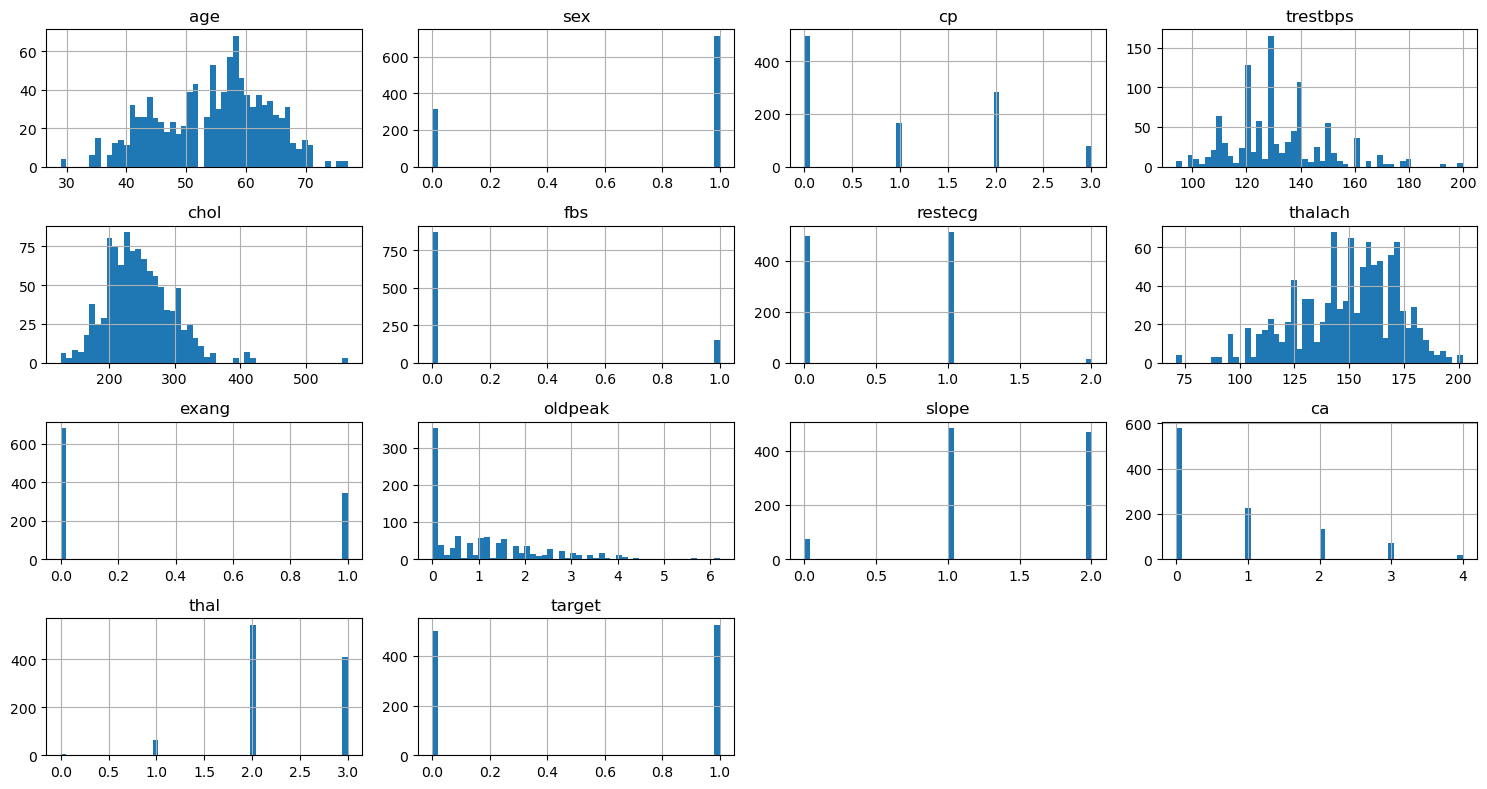

In [36]:
heart_data.hist(figsize=(15,8),bins=50)
plt.tight_layout()
plt.show()

Смотря на гистограмму данных:
- Имеется 5 фичей с продолжительными данными
- Распределение продолжительных данных выглядит как нормальное распределение, с выбросами
- Таргет сбалансирован

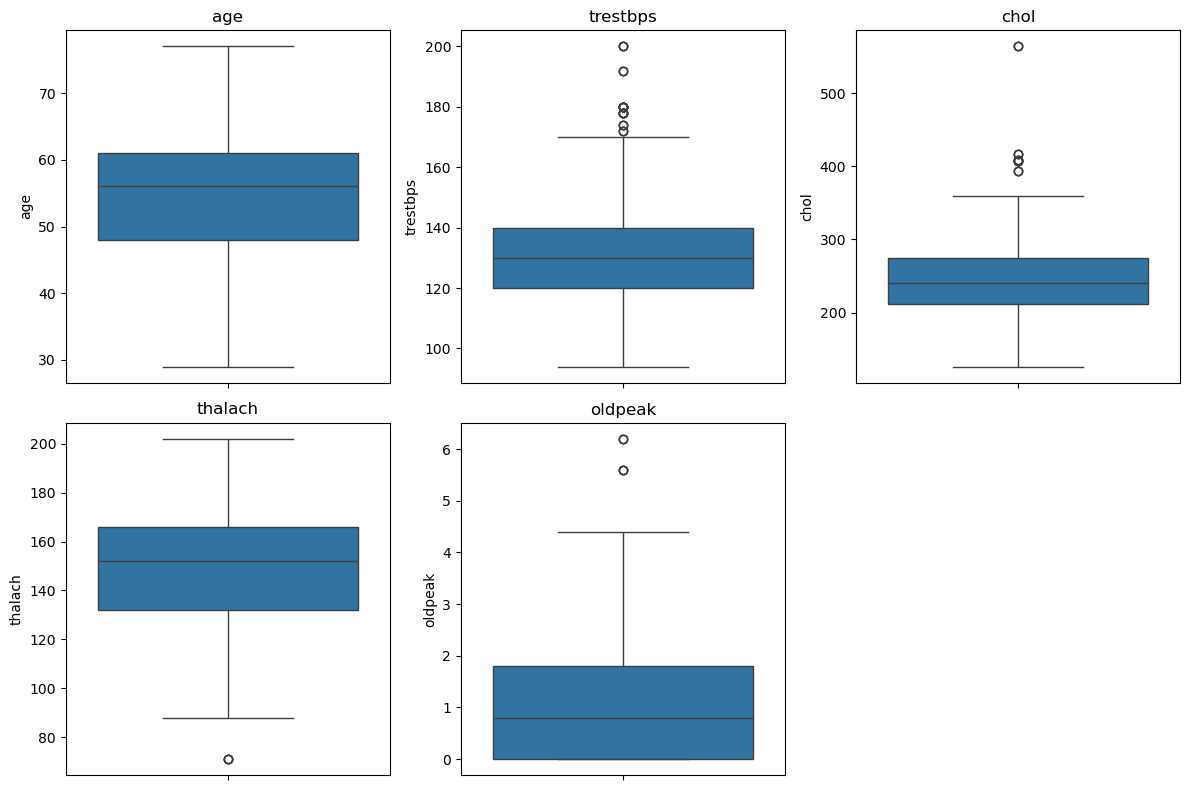

In [37]:
heart_cont_data = heart_data.loc[:, ["age", "trestbps", "chol", "thalach", "oldpeak"]]
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

for idx, col in enumerate(heart_cont_data.columns):
    sns.boxplot(data=heart_cont_data, y=col, ax=axs.flatten()[idx]) 
    axs.flatten()[idx].set_title(col)
for ax in axs.flatten()[len(heart_cont_data.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


Как и полагалось, большинство продолжительных данных имеют выбросы, которые нужно будет убрать

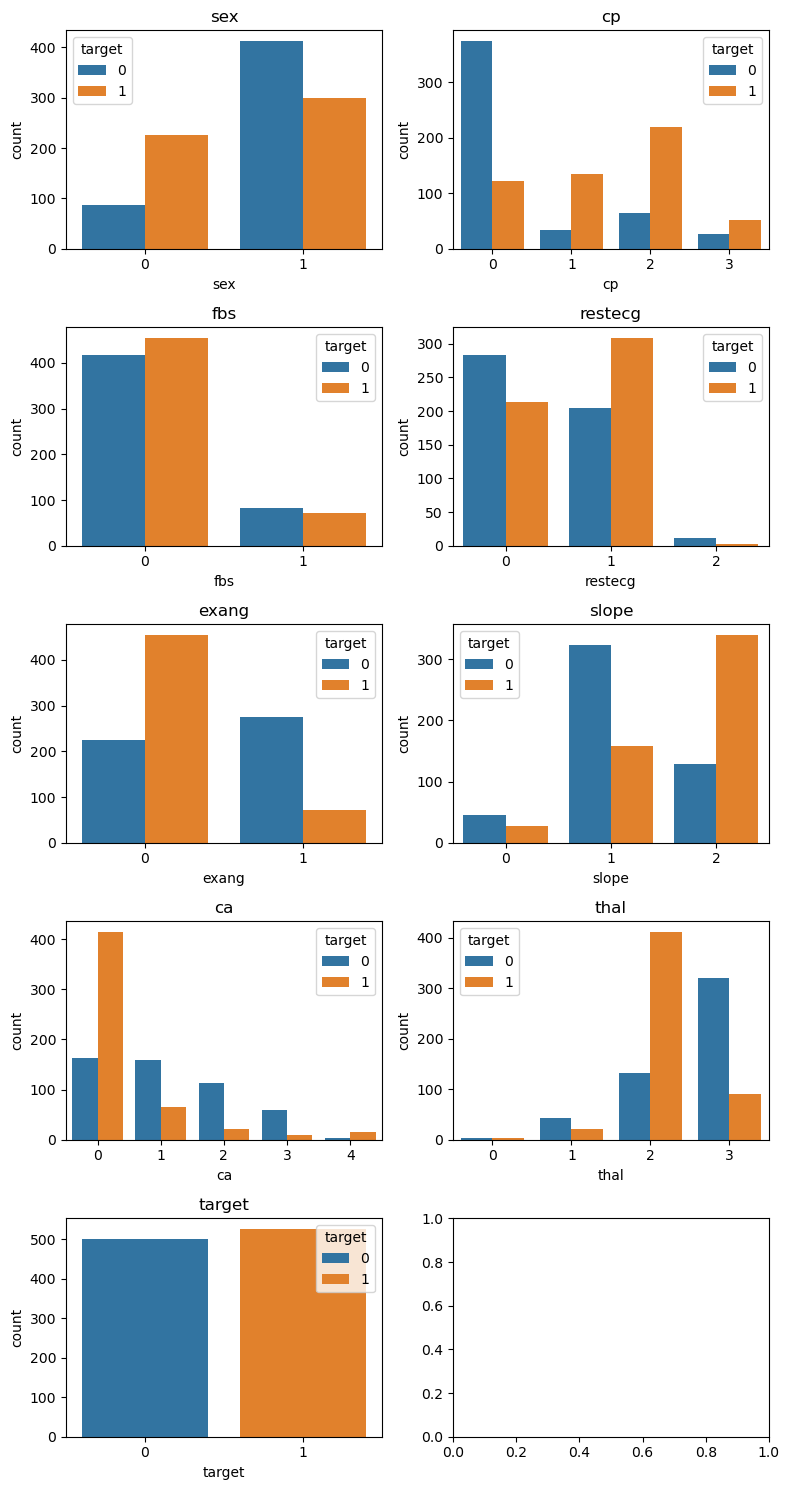

In [38]:
fig, axs = plt.subplots(5, 2, figsize=(8,15))
axs = axs.flatten()
for idx, col in enumerate([col for col in heart_data.columns if col not in heart_cont_data.columns ]):
    sns.countplot(data=heart_data, x=col, ax=axs[idx], hue="target")
    axs[idx].set_title(col)
fig.tight_layout()

**Распределения категориальных признаков показывают следующее**:
- Мужчины в нашей выборке имеют больше заболеваний сердца
- Люди с 1 и 2 видами грудной боли имеют больше заболеваний
- Уровень сахара в крови не имеет видимый эффект на заболевания
- Люди с аномалиями зубца ST так же имеют больше заболевания
- Чем больше кровяных сосудов у человека, тем экспоненциально меньше шанс заболевания
- thal 2, значительно повышает шанс на заболевание
- Чем больше наклон ST, тем больше шанс заболевания

Так как некоторые признаки не имеют линейной зависимости с таргетом, попробуем построить матрицу корреляций по spearman, чтобы уловить нелинейные зависимости

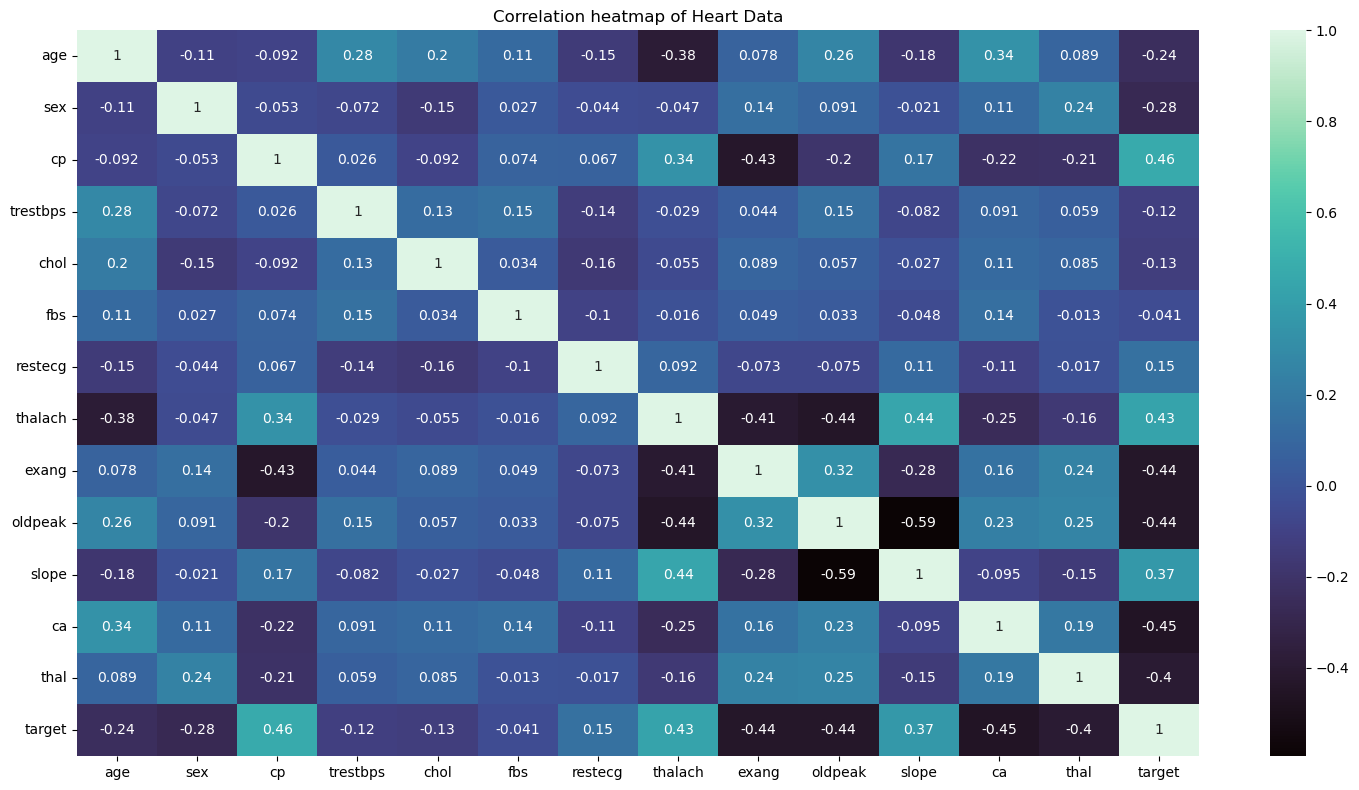

In [39]:
heart_corr_spearman = heart_data.corr(method="spearman")
plt.figure(figsize=(15,8))
sns.heatmap(heart_corr_spearman, annot=True, cmap="mako")
plt.title("Correlation heatmap of Heart Data")
plt.tight_layout()
plt.show()

Как и предполагалось, признак fbs не имеет значительного эффекта на таргет.
Остальные признаки имеют статистическую значимость

In [40]:
heart_data = heart_data.drop(columns="fbs")

Почистим данные от выбросов

In [41]:
outlier_count, outliers = getOutliers(heart_cont_data)
outlier_count_df = pd.DataFrame(data=[_[0] for _ in outlier_count.values()], index=outlier_count.keys(), columns=["Count"])
print(outlier_count_df.sort_values("Count", ascending=False))

print("Количество наблюдений до чистки от выбросов: {}".format(heart_data.shape[0]))
heart_clean_data = heart_data.drop(outliers)
print("Количество наблюдений после чистки: {}".format(heart_clean_data.shape[0]))
print("Всего выбросов удалено: {}".format(len(outliers)))

          Count
trestbps     30
chol         16
oldpeak       7
thalach       4
age           0
Количество наблюдений до чистки от выбросов: 1025
Количество наблюдений после чистки: 968
Всего выбросов удалено: 57


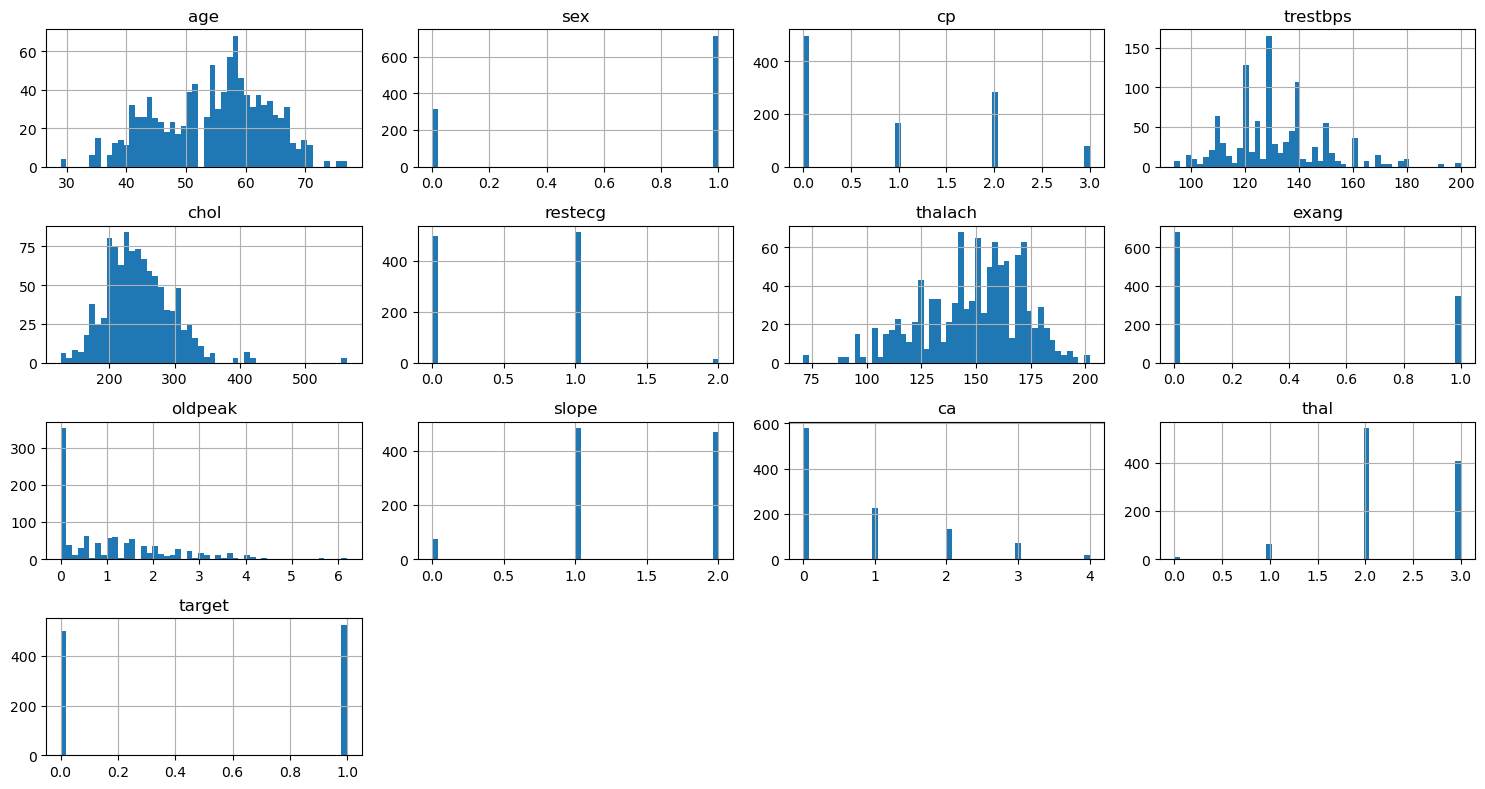

In [42]:
heart_data.hist(figsize=(15,8),bins=50)
plt.tight_layout()
plt.show()

In [43]:
heart_data.skew()

age        -0.248866
sex        -0.851449
cp          0.529455
trestbps    0.739768
chol        1.074073
restecg     0.180440
thalach    -0.513777
exang       0.692655
oldpeak     1.210899
slope      -0.479134
ca          1.261189
thal       -0.524390
target     -0.052778
dtype: float64

Поправим skew таких признаков как:
- chol

In [44]:
heart_data.loc[:, "chol"] = np.log(heart_data.loc[:, "chol"].astype("float"))

C:\Users\maksp\AppData\Local\Temp\ipykernel_17372\2505564221.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5.35658627 5.31320598 5.1590553  ... 5.6167711  5.53733427 5.23644196]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heart_data.loc[:, "chol"] = np.log(heart_data.loc[:, "chol"].astype("float"))


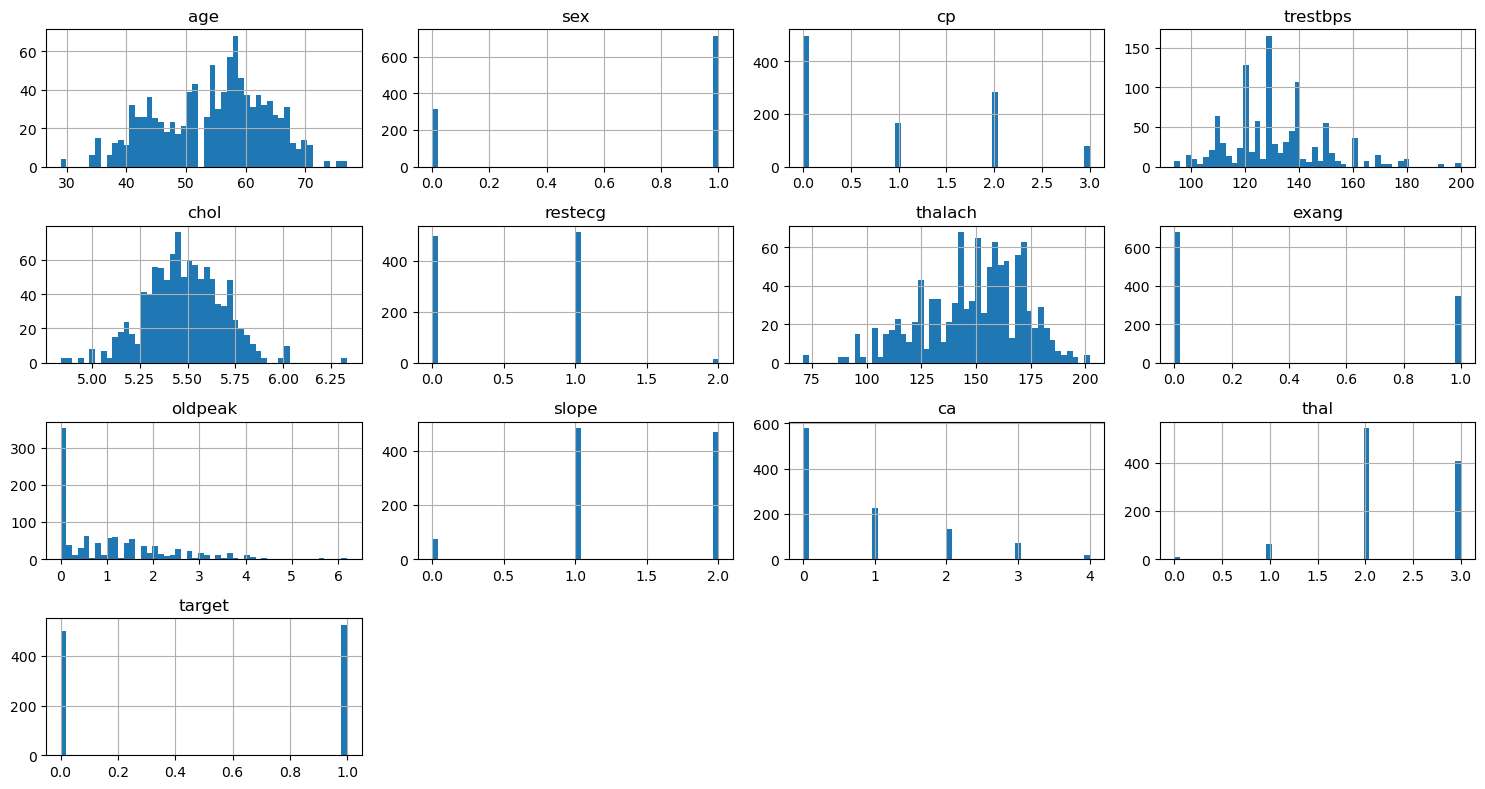

In [45]:
heart_data.hist(figsize=(15,8),bins=50)
plt.tight_layout()
plt.show()

### Задание 2. Визуализация

**2.1.** Посмотрите на соотношение классов в целевой переменной (`target`). Все ли в порядке?  
**Ответьте на вопрос:** почему, с вашей точки зрения, важно иметь представление о балансе классов в данных?  

**Подсказка:** Создайте столбчатую диаграмму, показывающую общее количество наблюдений для каждого значения целевой переменной.

С таргетом все впорядке, он сбалансирован. Это важно так как если классы не сбалансированы, то у модели не будет информации для предсказания менее представленного класса
<br>P.S: Все визуализации были показаны в EDA

**2.2.** Boxplot

**2.3.** Визуализируйте корреляции между всеми столбцами в наборе данных.

### Задание 3. Разделение данных
**3.1.** Разделите данные на признаки (X) и целевую переменную (y).


In [46]:
# Ваш код:
X = heart_data.drop(columns="target")
y = heart_data.loc[:, "target"]

**3.2.** Выполните разделение данных на обучающую и тестовую выборки с размером тестовой выборки 10% и установите параметр random_state равным 101.


In [47]:
# Ваш код:tra
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

### Задание 4. Модель
Перед тем как обучить модель, вы можете подготовить данные если они этого требуют.

**4.1.** Постройте модель и выполните её обучение.



In [48]:
# Ваш код:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=100, random_state=101)
log_reg.fit(X_train, y_train)


C:\Users\maksp\anaconda3\envs\ds_outpeer\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=101)

**4.2.** Попробуйте поэкспериментировать с различными значениями пороги (например, 0.3, 0.5, 0.7) и оцените, как изменение порога влияет на метрики вашей модели (например, точность, полнота, F1-меру).

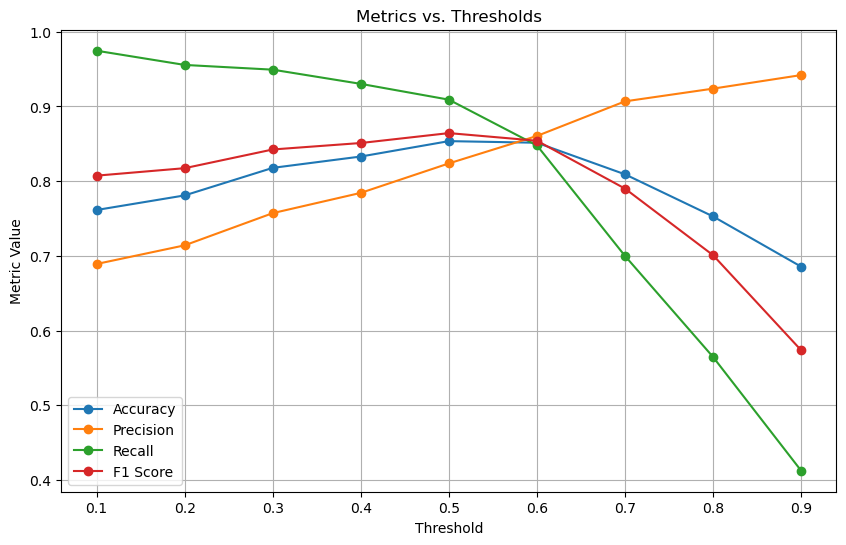

In [49]:
# Ваш код:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
probs_class_1 = log_reg.predict_proba(X_train)[:, 1]

accuracy, precision, recall, f1 = [], [], [], []
thresholds = np.arange(0.1, 1, 0.1)

for threshold in thresholds:
    preds = (probs_class_1 >= threshold).astype(int)
    accuracy.append(accuracy_score(y_train, preds))
    precision.append(precision_score(y_train, preds))
    recall.append(recall_score(y_train, preds))
    f1.append(f1_score(y_train, preds))

plt.figure(figsize=(10, 6))

plt.plot(thresholds, accuracy, label="Accuracy", marker='o')
plt.plot(thresholds, precision, label="Precision", marker='o')
plt.plot(thresholds, recall, label="Recall", marker='o')
plt.plot(thresholds, f1, label="F1 Score", marker='o')

plt.title("Metrics vs. Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.xticks(thresholds) 
plt.legend()
plt.grid()

plt.show()

**4.3.** Отметьте, какой порог даёт наилучшие метрики для вашей задачи.

После исследования показатели метрик с различными порогами:
- В нашем кейсе, мы хотим предсказывать как можно больше правильных случаев болезни сердца, поэтому мы ставим в приоритет **recall**
- Порог 0.3 подходящий, так как дает оптимальный баланс между recall и precision.

### Задание 5. Интерпретация
**5.1.** Создайте визуализацию коэффициентов модели с помощью barplot.  


*   Отобразите коэффициенты модели в виде столбчатой диаграммы, где на оси X будут признаки, а на оси Y — значения их коэффициентов.
*   Отсортируйте диаграмму по величине коэффициентов (по возрастанию).


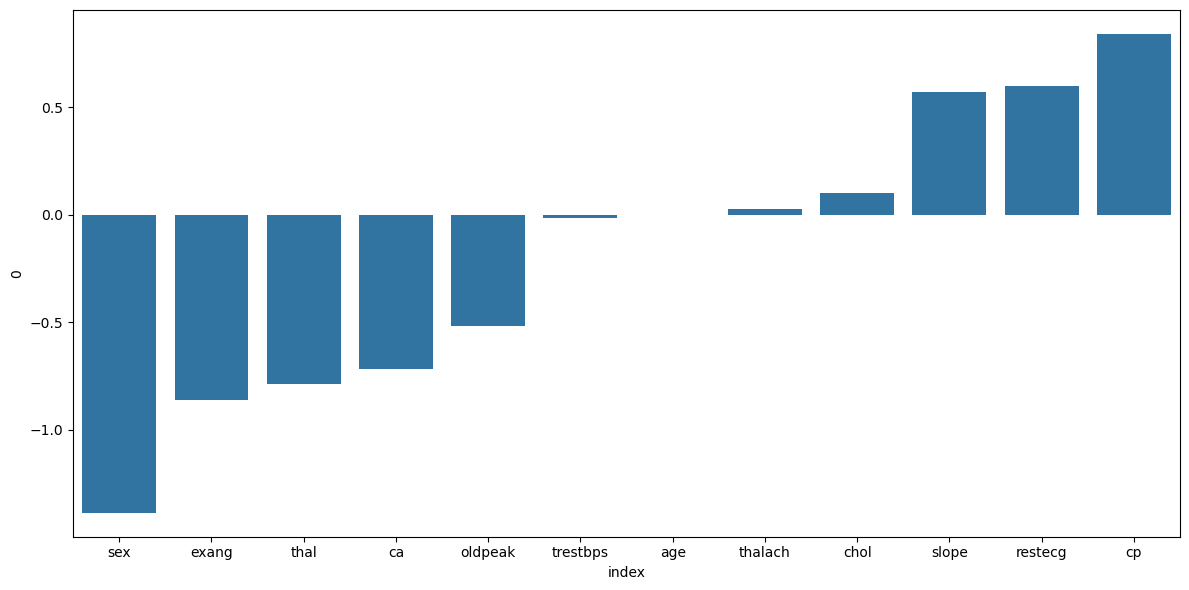

In [92]:
# Ваш код:
plt.figure(figsize=(12,6))
log_reg_coefs = pd.DataFrame(log_reg.coef_.T, index=X_train.columns)
log_reg_coefs = log_reg_coefs.sort_values(0)
sns.barplot(data=log_reg_coefs.reset_index(), x="index", y=0)
plt.tight_layout()
plt.show()

**5.2.** Используйте коэффициенты вашей логистической регрессии, чтобы интерпретировать влияние признаков на вероятность события $y = 1$. Для каждого признака рассчитайте $ e^\beta$ и объясните, как изменяются шансы события $y = 1$ при увеличении признака на $1$ единицу.


In [93]:
# Ваш код:
log_reg_coefs = log_reg_coefs.reset_index().rename(columns={"index":"feature", 0:"coef"})
log_reg_coefs["exponent"] = np.exp(log_reg_coefs["coef"])
log_reg_coefs["%_change_odds_toTarget"] = abs(1 - log_reg_coefs["exponent"]) * 100
log_reg_coefs["%_change_odds_toTarget"] = log_reg_coefs["%_change_odds_toTarget"].round(1)
log_reg_coefs.sort_values("%_change_odds_toTarget", ascending=False)

,feature,coef,exponent,%_change_odds_toTarget
11,cp,0.840206,2.316845,131.7
10,restecg,0.597306,1.817216,81.7
9,slope,0.568205,1.765095,76.5
0,sex,-1.385784,0.250128,75.0
1,exang,-0.860957,0.422757,57.7
2,thal,-0.787964,0.454770,54.5
3,ca,-0.715881,0.488761,51.1
4,oldpeak,-0.516447,0.596637,40.3
8,chol,0.101477,1.106805,10.7
7,thalach,0.024140,1.024434,2.4


**Результаты логистической регрессии**
| Предиктор | Изменение шанса Заболевания(в процентах) | Направление изменения | Вывод |
|---|---|---|---|
| cp | 131.7 | Положительное | Более высокий тип боли в груди увеличивает шансы на болезнь сердца на 131.7 |
| restecg | 81.7 | Положительное | 	Аномалии на ЭКГ увеличивают шансы на болезнь сердца на 81.7% |
| slope | 76.5 | Положительное | Более высокий наклон ST увеличивает шансы на болезнь сердца на 76.5% |
| sex | 75 | Отрицательное | Быть мужчиной уменьшает шансы на болезнь сердца на 75% |
| exang | 57.7 | Отрицательное | 	Стенокардия, вызванная физической нагрузкой, уменьшает шансы на 57.7% |
| thal | 54.5 | Отрицательное | 	Более высокие значения thal уменьшают шансы на болезнь сердца на 54.5% |
| ca | 51.1 | Отрицательное | Дополнительный крупный сосуд уменьшает шансы на болезнь сердца на 51.1% |
| oldpeak | 40.3 | Отрицательное | 	Более высокие значения oldpeak уменьшают шансы на 40.3%. |
| chol | 10.7 | Положительное | Более высокий уровень холестерина увеличивает шансы на 10.7% |
| thalach | 2.4 | Положительное | Более высокий максимальный пульс увеличивает шансы на болезнь сердца на 2.4% |
| trestbps | 1.5 | Отрицательное | 	Каждое увеличение давления в покое на 1 уменьшает шансы на 1.5% |
| age | 0.3 | Отрицательное | 	Каждый дополнительный год уменьшает шансы на болезнь сердца на 0.3% |

### Задание 6. Финальная ценка модели


**6.1** Оцените вашу модель на оставшихся 10% данных, используя тестовую выборку.


*   Создайте матрицу ошибок (Confusion Matrix).
*   Постройте графическое представление матрицы ошибок (Confusion Matrix Plot)




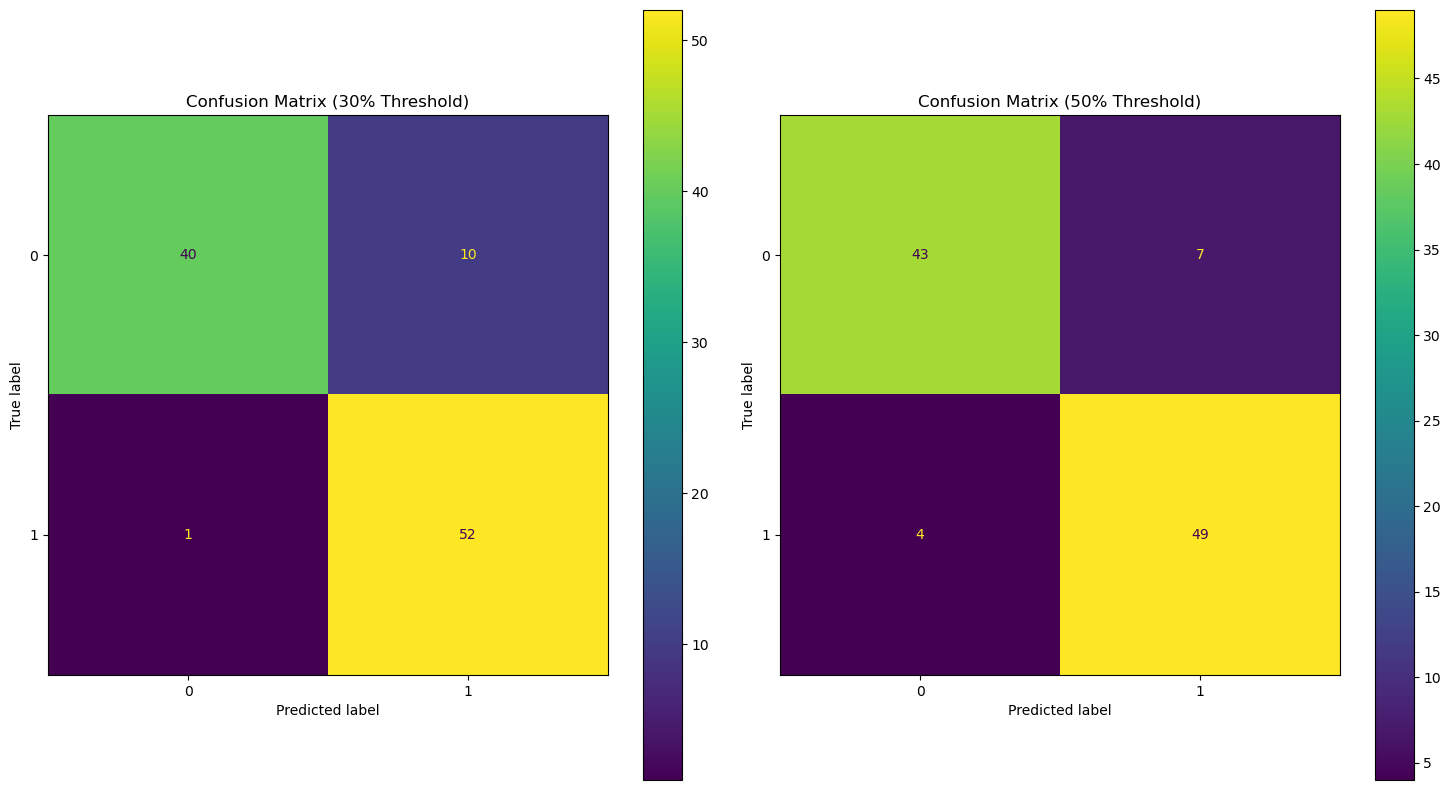

In [105]:
# Ваш код:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axs = plt.subplots(1, 2, figsize=(15,8))

test_preds_30perc = log_reg.predict_proba(X_test)[:, 1]
test_preds_30perc = (test_preds >= 0.3).astype(int)
c_matrix_30perc = confusion_matrix(y_test, test_preds_30perc)


test_preds_50perc = log_reg.predict(X_test)
c_matrix_50perc = confusion_matrix(y_test, test_preds_50perc)

ConfusionMatrixDisplay(c_matrix_30perc).plot(ax=axs[0])
axs[0].set_title("Confusion Matrix (30% Threshold)")

ConfusionMatrixDisplay(c_matrix_50perc).plot(ax=axs[1])
axs[1].set_title("Confusion Matrix (50% Threshold)")

plt.tight_layout()
plt.show()

Можно отчетливо видеть как наш фокус на recall и изменение порога с 0.5 на 0.3 меняет результат матрицы:
- Количество False Negative снизилось с 4 до 1 (В нашем случае только у одного человек на была выявлена болезнь сердца, что и было приоритетом)
- Количество False Positive повысилос с 7 до 10